In [1]:
import pandas as pd

# The file is imported 
df=pd.read_excel(r"C:\Users\jella sreeja\OneDrive\Desktop\PROJECT\data\OnlineRetail\Online Retail.xlsx")

# check how the data looks  
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# checking No of columns and  No of rows
df.shape

(541909, 8)

In [3]:
# check overall info 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [5]:
# checking negative quantites that are not cancellations 
df[(~df['InvoiceNo'].astype(str).str.startswith('C')) & (df['Quantity'] < 0)]['Description'].value_counts()

Description
check                    120
damages                   45
damaged                   42
?                         41
sold as set on dotcom     20
                        ... 
lost??                     1
wet                        1
wet boxes                  1
????damages????            1
lost                       1
Name: count, Length: 138, dtype: int64

In [6]:
# ? and ???? rows needed to be checked before they are added to stock_adjustments/losses/profits/just delete the rows

df[df['Description'].isin(['?', '????'])][['InvoiceNo', 'Quantity', 'UnitPrice', 'CustomerID', 'Country']]

,InvoiceNo,Quantity,UnitPrice,CustomerID,Country
7313,537032,-30,0.0,NaN,United Kingdom
21518,538090,-723,0.0,NaN,United Kingdom
38261,539494,752,0.0,NaN,United Kingdom
43662,540100,-106,0.0,NaN,United Kingdom
50806,540558,-29,0.0,NaN,United Kingdom
51673,540651,-290,0.0,NaN,United Kingdom
68920,541882,-57,0.0,NaN,United Kingdom
78235,542861,-207,0.0,NaN,United Kingdom
94765,544410,-741,0.0,NaN,United Kingdom
97643,544649,-400,0.0,NaN,United Kingdom


In [7]:
# checking the missing values 
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
# checking if the description = null has the same stockcode as one the with description != null
df[df['Description'].isnull()]['StockCode'].value_counts().head(10)

StockCode
23084    10
35965    10
22084     9
22451     6
22501     5
21784     5
21033     5
22866     5
23348     5
21067     5
Name: count, dtype: int64

In [9]:
# its verified Null description has StockCode 
# Now check if  the StockCode is same or not 
df[df['StockCode'] == '23084']['Description'].value_counts()
# Its empty so just exclude the Null Description for Product level Analysis

Series([], Name: count, dtype: int64)

In [10]:
# Finding the duplicates 
df.duplicated().sum()

np.int64(5268)

In [11]:
# check Zero UnitPrice rows 
df[df['UnitPrice'] == 0].shape[0]

2515

In [12]:
# check other rows with Zero unitprice
df[df['UnitPrice'] == 0]['Description'].value_counts().head(10)

Description
check                            159
?                                 47
damages                           45
damaged                           43
found                             25
sold as set on dotcom             20
adjustment                        16
Damaged                           14
Unsaleable, destroyed.             9
FRENCH BLUE METAL DOOR SIGN 1      9
Name: count, dtype: int64

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [14]:
## Deleting Rows with Invalid Descriptions(? and ????)

df = df[~df['Description'].isin(['?', '????'])]


In [15]:
# put all the InvoiceNo starts with C(Cancellations) into Cancellations
Cancellations=df[(df['InvoiceNo'].astype(str).str.startswith('C'))]
# delete them from the main dataframe df 
df=df[~df['InvoiceNo'].astype(str).str.startswith('C')]


In [16]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [17]:
#removing the InvoiceNo doesnt starts with C and Quantity <0
stock_adjustments=df[(~df['InvoiceNo'].astype(str).str.startswith('C')) & (df['Quantity'] < 0)]

In [18]:
df = df[~((~df['InvoiceNo'].astype(str).str.startswith('C')) & (df['Quantity'] < 0))]

In [19]:
# Separating the zero unit price items to the zero_price
zero_price = df[df['UnitPrice'] == 0]

In [20]:
# adding the zero_price and stock_adjustments to the stock_adjustments cause they dont create much value to the overall revenue
stock_adjustments = pd.concat([stock_adjustments,zero_price])

In [21]:
# removing zero unitprice means keeping only the non zero unitprices in the df
df = df[df['UnitPrice'] > 0]


In [22]:
#removing the duplicates from the dataset
df=df.drop_duplicates()

In [23]:
# coverting the customerid datatype from float to int (For customer analysis delete the customers with NaN but for revenue analysis keep them)
df['CustomerID'] = df['CustomerID'].astype('Int64')
# I in Int64 works for well when NaN values present unlike the regular int64


In [24]:
# Lst step of cleaning the data Drawing the Reveue
df['Revenue'] = df['UnitPrice'] * df['Quantity']

In [25]:
# Final check for correctness
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Description  524878 non-null  object        
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[ns]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   392692 non-null  Int64         
 7   Country      524878 non-null  object        
 8   Revenue      524878 non-null  float64       
dtypes: Int64(1), datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 40.5+ MB


In [26]:
# EDA

# Exploratory Data Analysis 

In [27]:
df['Revenue'].sum()

np.float64(10642110.804)

In [28]:
# extract month from the InvoiceDate
df['Month']= df['InvoiceDate'].dt.month

In [29]:
# Total revenue per month 
Monthly_Revenue= df.groupby('Month')['Revenue'].sum()


In [30]:
print(Monthly_Revenue)

Month
1      689811.610
2      522545.560
3      716215.260
4      536968.491
5      769296.610
6      760547.010
7      718076.121
8      757841.380
9     1056435.192
10    1151263.730
11    1503866.780
12    1459243.060
Name: Revenue, dtype: float64


In [31]:
# Importing Visualization libraries 
import matplotlib.pyplot as plt 
import seaborn as sns

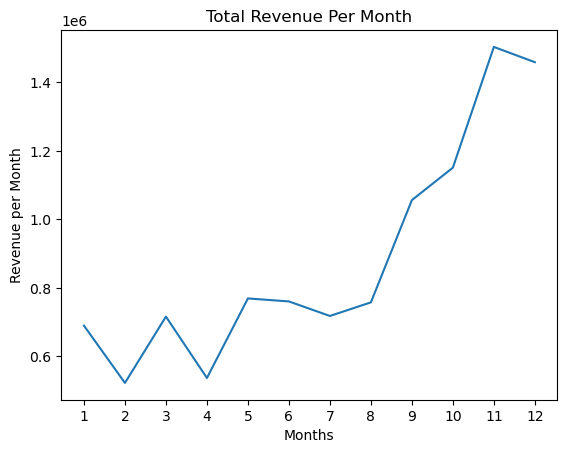

In [32]:
# Line Chart representation of the Monthly Revenue
plt.plot(Monthly_Revenue)
plt.title('Total Revenue Per Month')
plt.xlabel('Months')
plt.ylabel('Revenue per Month')
plt.xticks(range(1,13))
plt.show()

In [33]:
df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [34]:
# in the above products DOTCOM POSTAGE , POSTAGE , Manual are not the products so filter them out from the product analysis cause they are useful whiile revenue analysis
df_products = df[~df['Description'].isin(['DOTCOM POSTAGE', 'POSTAGE', 'Manual'])]

# Finding Top products based on description and revenue

In [35]:
# Now after filtering out them the  top 10 products are 
df_products.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
CHILLI LIGHTS                          54096.36
Name: Revenue, dtype: float64

In [36]:
# Only the top Products  
top_products = df_products.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

Text(0.5, 1.0, 'Top 10 products revenue')

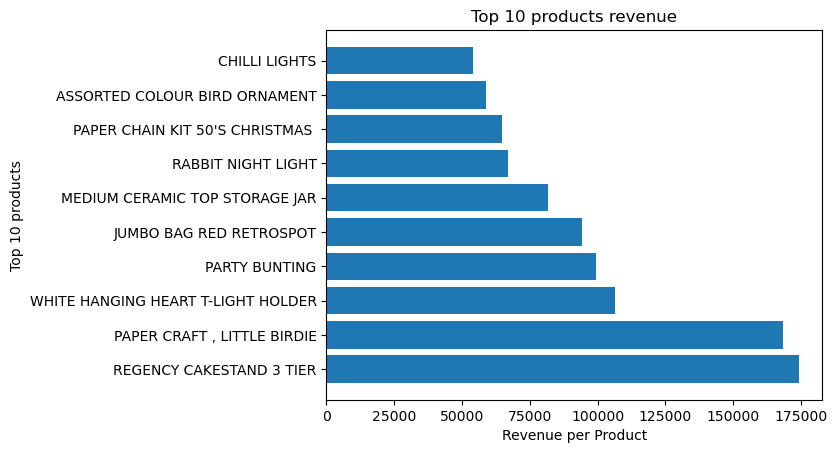

In [37]:
# visualization of these top products 
plt.barh(top_products.index,top_products.values)
plt.xlabel('Revenue per Product')
plt.ylabel('Top 10 products')
plt.title('Top 10 products revenue')


#  Finding the Top customers 

In [38]:
df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: Revenue, dtype: float64

In [39]:
# Only the top Products  
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

In [40]:
print(top_customers)

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: Revenue, dtype: float64


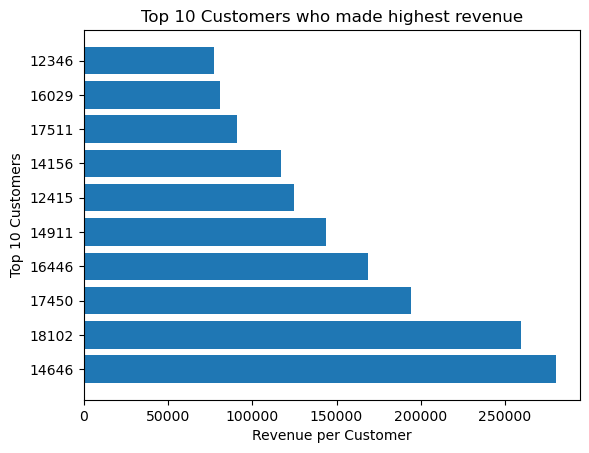

In [41]:
# visualization of these top customers 
plt.barh(top_customers.index.astype(str),top_customers.values)
plt.xlabel('Revenue per Customer')
plt.ylabel('Top 10 Customers')
plt.title('Top 10 Customers who made highest revenue')
plt.show()

# Which countries buy the most

In [42]:
top_countries=df.groupby('Country')['Revenue'].sum().sort_values(ascending= False).head(10)

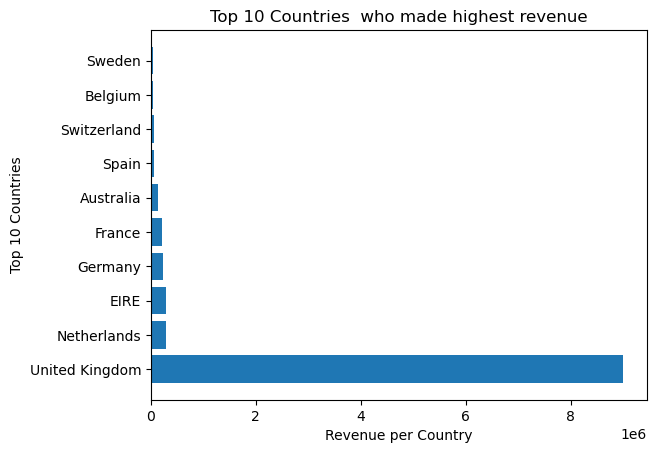

In [43]:
# visualization of the top countries who made the most revenue
plt.barh(top_countries.index,top_countries.values)
plt.xlabel('Revenue per Country')
plt.ylabel('Top 10 Countries')
plt.title('Top 10 Countries  who made highest revenue')
plt.show()

In [44]:
# But the graph shows UK is the  highest in such a way that the other countries are almost invisible
df_countries= df[~df['Country'].isin(['United Kingdom'])]


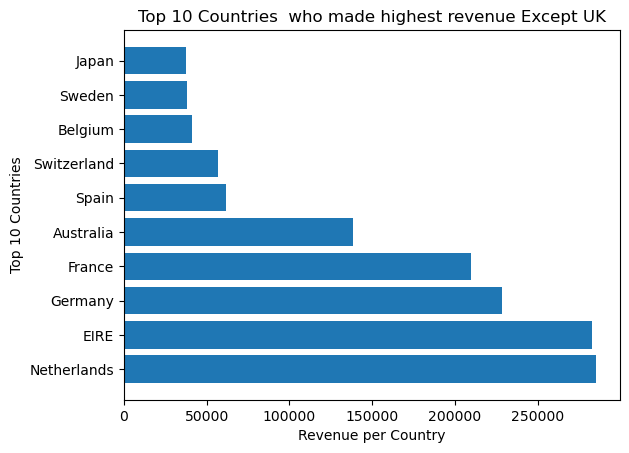

In [45]:
# Now Redo the groupby to clearly see how much revenue made by other countries
top_countries=df_countries.groupby('Country')['Revenue'].sum().sort_values(ascending= False).head(10)
# visualization of the top countries who made the most revenue other than the UK
plt.barh(top_countries.index,top_countries.values)
plt.xlabel('Revenue per Country')
plt.ylabel('Top 10 Countries')
plt.title('Top 10 Countries  who made highest revenue Except UK')
plt.show()

# Which Day of the  week made most revenue

In [46]:
df['Day']= df['InvoiceDate'].dt.day_name()

In [47]:

# Now do the groupby to clearly see how much revenue made on each day and highest on which day 
highest_day=df.groupby('Day')['Revenue'].sum().sort_values(ascending= False)


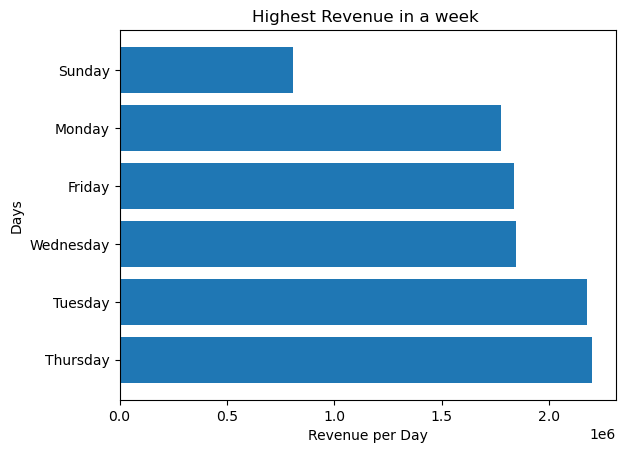

In [48]:
# visualization of the top countries who made the most revenue other than the UK
plt.barh(highest_day.index,highest_day.values)
plt.xlabel('Revenue per Day')
plt.ylabel('Days')
plt.title('Highest Revenue in a week ')
plt.show()

In [49]:
df['Day'].value_counts()

Day
Thursday     100213
Tuesday       98726
Monday        92466
Wednesday     91467
Friday        79667
Sunday        62339
Name: count, dtype: int64

# Repeated Customers vs One time buyers

In [50]:
# Finding the unique orders placed by each customer
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()
print(customer_orders)

CustomerID
12346     1
12347     7
12348     4
12349     1
12350     1
         ..
18280     1
18281     1
18282     2
18283    16
18287     3
Name: InvoiceNo, Length: 4338, dtype: int64


In [51]:
one_time_customer=customer_orders[customer_orders==1]
repeated_customers=customer_orders[customer_orders>1]
print(len(one_time_customer))
print(len(repeated_customers))


1493
2845


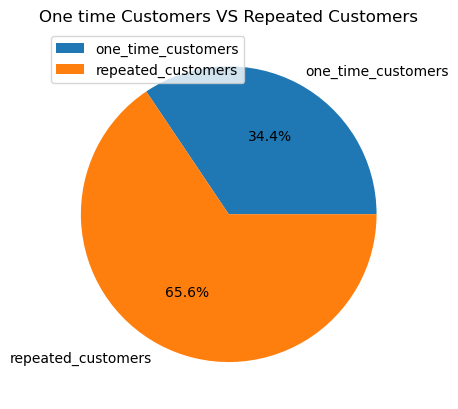

In [52]:
# visualizing them using pie chart cause it represents the parts of a whole
plt.pie([len(one_time_customer),len(repeated_customers)], labels =['one_time_customers' ,'repeated_customers'] ,autopct='%1.1f%%')
plt.title('One time Customers VS Repeated Customers')
plt.legend(loc='upper left')

# RFM Analysis  and  customer segmentation

In [53]:
# RFM Analysis 
reference_date=df['InvoiceDate'].max()
print(reference_date)

2011-12-09 12:50:00


In [54]:
# Grouping customers based on CustomerId 
rfm = df.groupby('CustomerID').agg({ 'InvoiceDate' : 'max', 'InvoiceNo' : 'nunique', 'Revenue' : 'sum'})
print(rfm)

                   InvoiceDate  InvoiceNo   Revenue
CustomerID                                         
12346      2011-01-18 10:01:00          1  77183.60
12347      2011-12-07 15:52:00          7   4310.00
12348      2011-09-25 13:13:00          4   1797.24
12349      2011-11-21 09:51:00          1   1757.55
12350      2011-02-02 16:01:00          1    334.40
...                        ...        ...       ...
18280      2011-03-07 09:52:00          1    180.60
18281      2011-06-12 10:53:00          1     80.82
18282      2011-12-02 11:43:00          2    178.05
18283      2011-12-06 12:02:00         16   2045.53
18287      2011-10-28 09:29:00          3   1837.28

[4338 rows x 3 columns]


In [55]:
# Rename columns
rfm.columns = ['LastPurchaseDate', 'Frequency', 'Monetary']

In [56]:
# Calculate recency ( Substract last date from the reference)
rfm['Recency'] = (reference_date - rfm['LastPurchaseDate']).dt.days

In [57]:
rfm.head()

,LastPurchaseDate,Frequency,Monetary,Recency
CustomerID,,,,
12346,2011-01-18 10:01:00,1,77183.60,325
12347,2011-12-07 15:52:00,7,4310.00,1
12348,2011-09-25 13:13:00,4,1797.24,74
12349,2011-11-21 09:51:00,1,1757.55,18
12350,2011-02-02 16:01:00,1,334.40,309


In [58]:
# Since we dont need LastpurchaseDate delete it 
rfm =  rfm.drop(columns=['LastPurchaseDate'])
print(rfm)

            Frequency  Monetary  Recency
CustomerID                              
12346               1  77183.60      325
12347               7   4310.00        1
12348               4   1797.24       74
12349               1   1757.55       18
12350               1    334.40      309
...               ...       ...      ...
18280               1    180.60      277
18281               1     80.82      180
18282               2    178.05        7
18283              16   2045.53        3
18287               3   1837.28       42

[4338 rows x 3 columns]


# Customer Segmentation ( Dividing the dataset into 5 groups )

In [59]:
# reverse pattern cause in recency low recency = high score  
rfm['R_score']=pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])

In [60]:
# Frequency Scores ( high frquency = high score )  
# Used duplicates to delete but it wont be possible cause This error happens because many customers have the same frequency value — like a lot of customers bought only once, so the bin edges overlap.(rfm['F_score'] = pd.qcut(rfm['Frequency'], q=5, labels=[1,2,3,4,5], duplicates='drop'))
# rank(method='first') assigns unique ranks so no duplicate bin edges.
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])

In [61]:
# Monetary  Scores ( high Monetary  = high score ) 
rfm['M_score']=pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5])

In [62]:
print(rfm.head())

            Frequency  Monetary  Recency R_score F_score M_score
CustomerID                                                      
12346               1  77183.60      325       1       1       5
12347               7   4310.00        1       5       5       5
12348               4   1797.24       74       2       4       4
12349               1   1757.55       18       4       1       4
12350               1    334.40      309       1       1       2


In [63]:
# Now combine those R_score , F_score, M_score ( 5, 5, 5 into 555)
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) + 
    rfm['F_score'].astype(str) + 
    rfm['M_score'].astype(str)
)

In [64]:
rfm['RFM_Score'].head()

CustomerID
12346    115
12347    555
12348    244
12349    414
12350    112
Name: RFM_Score, dtype: object

In [65]:
#  Assigning the Segment labels  based on few conditions 
def segment_customer(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Loyal Customers"
    elif r >= 4:
        return "New  Customers"
    elif r <= 2 and f >= 3:
        return "At Risk"
    else:
        return "Lost Customers"

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [66]:
# Overall summary of lost , loyal , champions , at risk , New Customers
rfm['Segment'].value_counts()

Segment
Lost Customers     1416
Loyal Customers    1003
Champions           957
At Risk             643
New  Customers      319
Name: count, dtype: int64

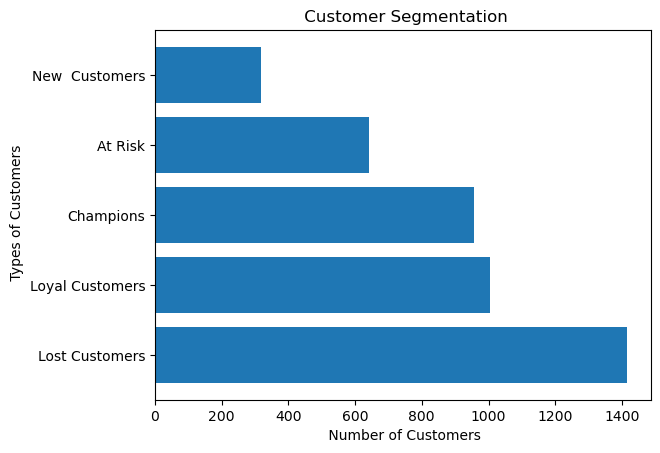

In [67]:
# plotting the customer segmentation
segment_counts = rfm['Segment'].value_counts()
plt.barh(segment_counts.index, segment_counts.values)
plt.xlabel(" Number of Customers")
plt.ylabel(" Types of Customers")
plt.title(" Customer Segmentation") 
plt.show()


Text(0.5, 1.0, 'Correlation HeatMap')

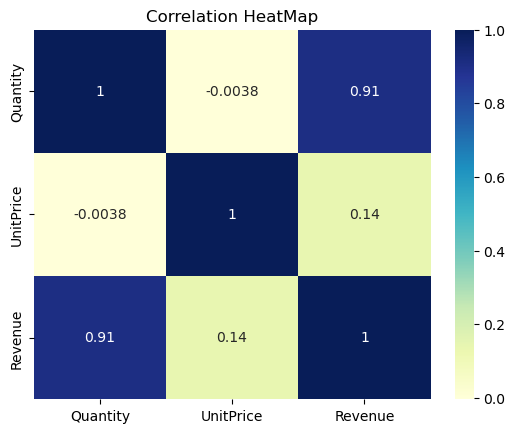

In [68]:
# Correlation Heatmaps to show the relationships between every attritubte to each other attribute( many to many kind)
import seaborn as sns 
corr_matrix= df[['Quantity','UnitPrice','Revenue']].corr()
sns.heatmap(corr_matrix , cmap ="YlGnBu" , annot = True)
plt.title('Correlation HeatMap')


# Done the  EDA and Now exporting the cleaned datset to powerbi before that save it as cleaned_online_retail.csv and alsp rfm_segments 


In [69]:
df.to_csv('cleaned_online_retail.csv', index=False)
rfm.to_csv('rfm_segments.csv', index=False)

# Cohort  Analysis 
( To check group of people who made their first purchase and how many of them returned and when& which month did they returned )

In [70]:
# Making sure InvoiceDate is in Datetimeformat
df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])  

In [71]:
# extracting just year and month frim InvoiceDate
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M') 

In [72]:
# grouping customers and finding the earliest InvoiceMonth 
df_cohort = df.groupby('CustomerID')['InvoiceMonth'].min().reset_index()

In [73]:
df_cohort.columns= ['CustomerID' , 'CohortMonth']

In [74]:
df_cohort.head()

,CustomerID,CohortMonth
0,12346,2011-01
1,12347,2010-12
2,12348,2010-12
3,12349,2011-11
4,12350,2011-02


In [75]:
# Merge this CohortMonth into df so for every trasaction we know which cohort that customer belongs to 
df= df.merge(df_cohort , on ='CustomerID', how = 'left')

In [76]:
# Extract the month from the invoicedate
df['OrderMonth'] = df['InvoiceDate'].dt.to_period('M') 

In [77]:
# drop missing dates values 
df=df.dropna(subset=['CohortMonth'])

In [78]:
# find the difference between last and first purchase of a customer( no of months ) 
from operator import attrgetter
df['CohortIndex']= (df['OrderMonth']-df['CohortMonth']).apply(attrgetter('n'))

In [79]:
print(df[['CustomerID','CohortMonth','OrderMonth','CohortIndex']].tail(10))
# 0 - first purchase 
# 1 - one month later from the first purchase ..etc 

        CustomerID CohortMonth OrderMonth  CohortIndex
524868       12680     2011-08    2011-12            4
524869       12680     2011-08    2011-12            4
524870       12680     2011-08    2011-12            4
524871       12680     2011-08    2011-12            4
524872       12680     2011-08    2011-12            4
524873       12680     2011-08    2011-12            4
524874       12680     2011-08    2011-12            4
524875       12680     2011-08    2011-12            4
524876       12680     2011-08    2011-12            4
524877       12680     2011-08    2011-12            4


In [80]:
# how many customers from each cohort came back in each month 
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_data.columns=['CohortMonth' ,'CohortIndex','CustomerCount']
cohort_pivot = cohort_data.pivot_table(index='CohortMonth', columns='CohortIndex', values='CustomerCount')
print(cohort_pivot.head())

CohortIndex     0      1      2      3      4      5      6      7      8   \
CohortMonth                                                                  
2010-12      885.0  324.0  286.0  340.0  321.0  352.0  321.0  309.0  313.0   
2011-01      417.0   92.0  111.0   96.0  134.0  120.0  103.0  101.0  125.0   
2011-02      380.0   71.0   71.0  108.0  103.0   94.0   96.0  106.0   94.0   
2011-03      452.0   68.0  114.0   90.0  101.0   76.0  121.0  104.0  126.0   
2011-04      300.0   64.0   61.0   63.0   59.0   68.0   65.0   78.0   22.0   

CohortIndex     9      10     11     12  
CohortMonth                              
2010-12      350.0  331.0  445.0  235.0  
2011-01      136.0  152.0   49.0    NaN  
2011-02      116.0   26.0    NaN    NaN  
2011-03       39.0    NaN    NaN    NaN  
2011-04        NaN    NaN    NaN    NaN  


In [81]:
# Retention percentages (Decreased percentage )
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100
print(retention.head())

CohortIndex     0     1     2     3     4     5     6     7     8     9   \
CohortMonth                                                                
2010-12      100.0  36.6  32.3  38.4  36.3  39.8  36.3  34.9  35.4  39.5   
2011-01      100.0  22.1  26.6  23.0  32.1  28.8  24.7  24.2  30.0  32.6   
2011-02      100.0  18.7  18.7  28.4  27.1  24.7  25.3  27.9  24.7  30.5   
2011-03      100.0  15.0  25.2  19.9  22.3  16.8  26.8  23.0  27.9   8.6   
2011-04      100.0  21.3  20.3  21.0  19.7  22.7  21.7  26.0   7.3   NaN   

CohortIndex    10    11    12  
CohortMonth                    
2010-12      37.4  50.3  26.6  
2011-01      36.5  11.8   NaN  
2011-02       6.8   NaN   NaN  
2011-03       NaN   NaN   NaN  
2011-04       NaN   NaN   NaN  


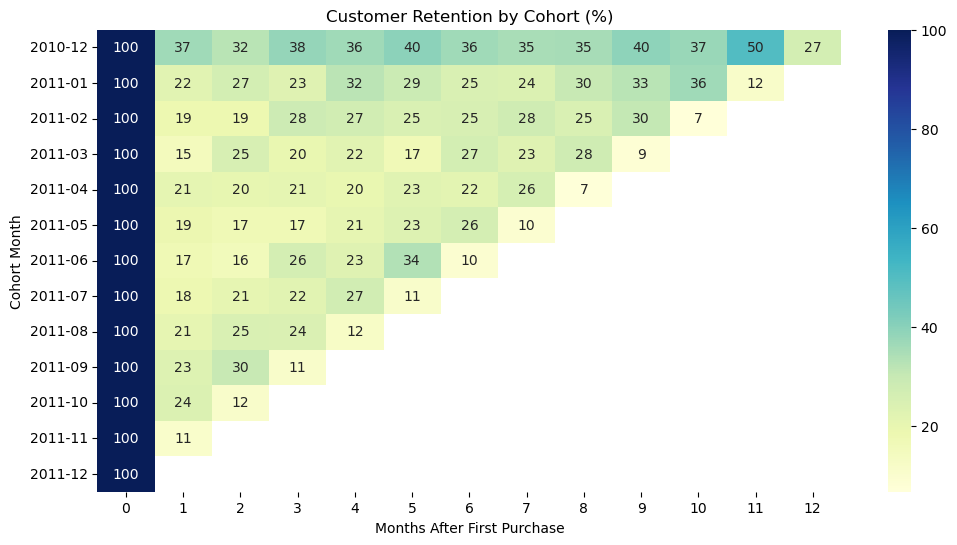

In [82]:
# Cohort analysis using heatmap

plt.figure(figsize=(12, 6))
sns.heatmap(retention, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Customer Retention by Cohort (%)')
plt.xlabel('Months After First Purchase')
plt.ylabel('Cohort Month')
plt.show()

In [83]:
retention.to_csv('cohort_retention.csv')

# Churn prediction 
 To identify which customers are likely to stop buying

In [84]:
# Creating the churn column 
rfm['Churn'] = rfm['Segment'].apply(lambda x: 1 if x == 'Lost Customers' else 0)

In [85]:
rfm[['Segment', 'Churn']].head()

,Segment,Churn
CustomerID,,
12346,Lost Customers,1
12347,Champions,0
12348,At Risk,0
12349,New Customers,0
12350,Lost Customers,1


In [89]:
rfm['Churn'].value_counts()

Churn
0    2922
1    1416
Name: count, dtype: int64

In [91]:
# Select the features 
X = rfm[['Recency' , 'Frequency' , 'Monetary']]
y= rfm['Churn']

In [98]:
# Train Test Split 
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.2 , random_state= 42)

In [99]:
# Using logistic Regression Model Train the model
from sklearn.linear_model import LogisticRegression
model= LogisticRegression()
model.fit(X_train , y_train)

LogisticRegression()

In [100]:
# Make predictions
y_pred= model.predict(X_test)

In [103]:
# Checking the Accuracy (Model TP and TN model makes out of total predictions)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test , y_pred)
print("Accuarcy:" , accuracy)


Accuarcy: 0.8928571428571429


In [ ]:
# Finding which feature has more impact on churn
feature_importance = pd.DataFrame({
    'Feature': ['Recency', 'Frequency', 'Monetary'],
    'Coefficient': model.coef_[0]
})
print(feature_importance)

     Feature  Coefficient
0    Recency     0.014524
1  Frequency    -3.340398
2   Monetary     0.000007


In [105]:
df.to_csv('cleaned_online_retail.csv', index=False)
rfm.to_csv('rfm_segments.csv', index=False)
retention.to_csv('cohort_retention.csv')

In [107]:
retention.index = retention.index.astype(str)
retention.columns = retention.columns.astype(str)
retention.to_csv('cohort_retention.csv', index=True)

In [108]:
feature_importance.to_csv('feature_importance.csv', index=False)